In [1]:
from pathlib import Path
import pandas as pd

#load metadata (need the two excel/csv files in the data subfolder)
REPO_NAME = "earthwatch-cnn"

BASE_DIR = next(
    p for p in Path.cwd().parents
    if p.name == REPO_NAME)

DATA_DIR = BASE_DIR / "data"

quality_df = pd.read_csv(DATA_DIR / "Global_Data_Set_XvsX_0.csv")
photo_df = pd.read_excel(DATA_DIR / "photo_manifest.xlsx")

# Merge on the ID columns
data = pd.merge(photo_df,quality_df, left_on='feature_global_id', right_on='GlobalID')

# Build image paths for image processing
IMAGE_DIR = DATA_DIR / "Great_UK_water_blitz"

data["image_path"] = data["saved_filename"].apply(lambda x: IMAGE_DIR / x)

/tmp/ipykernel_1050/3707237593.py:13: DtypeWarning: Columns (2,7,23,24,28,30,32,34,35,41,97,98,100,101,102,103,104,110,112,113,114,116,119,120,121,137) have mixed types. Specify dtype option on import or set low_memory=False.
  quality_df = pd.read_csv(DATA_DIR / "Global_Data_Set_XvsX_0.csv")


In [3]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

IMG_SIZE = (128, 128)

def valid_image(path):
    img = cv2.imread(path)
    return img is not None

data = data[data['image_path'].apply(valid_image)] #<class 'pandas.core.frame.DataFrame'> (8996, 156)

def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype("float32") / 255.0
    return img

[ WARN:0@19.405] global loadsave.cpp:275 findDecoder imread_('/home/teaching/earthwatch-cnn/data/Great_UK_water_blitz/Feature_63_Attachment_50_photo-20231008-160246.jpg'): can't open/read file: check file path/integrity
[ WARN:0@19.405] global loadsave.cpp:275 findDecoder imread_('/home/teaching/earthwatch-cnn/data/Great_UK_water_blitz/Feature_64_Attachment_51_photo-20231010-163450.jpg'): can't open/read file: check file path/integrity
[ WARN:0@19.405] global loadsave.cpp:275 findDecoder imread_('/home/teaching/earthwatch-cnn/data/Great_UK_water_blitz/Feature_65_Attachment_52_photo-20231014-133426.jpg'): can't open/read file: check file path/integrity
[ WARN:0@19.405] global loadsave.cpp:275 findDecoder imread_('/home/teaching/earthwatch-cnn/data/Great_UK_water_blitz/Feature_66_Attachment_53_photo-20231014-145039.jpg'): can't open/read file: check file path/integrity
[ WARN:0@19.405] global loadsave.cpp:275 findDecoder imread_('/home/teaching/earthwatch-cnn/data/Great_UK_water_blitz/Fe

In [4]:
display(data)

,downloaded_utc,layer_title,layer_id,feature_object_id,feature_global_id,geometry_x,geometry_y,attachment_id,attachment_global_id,attachment_name,...,feedback_score,County,RBD_NAME,MNCAT_NAME,Nitrate (mg/L) MID,Phosphate (mg/L) MID,Photo URL,x,y,image_path
3979,2025-11-26T17:48:11Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,12,f1a757f1-0d0d-4dc5-943d-d2c03e1ba78a,-4.011572,52.434782,6,120e143f-b55e-4c10-aced-8b8f36ab4561,photo-20240525-180858.jpg,...,1,Dyfed,Western Wales,Teifi and North Ceredigion,0.75,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-4.011572,52.434782,/home/teaching/earthwatch-cnn/data/Great_UK_wa...
3980,2025-11-26T17:48:17Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,13,3ba0caef-1459-47ca-bcff-bb6a8b253ca4,-1.997459,53.932339,7,01b85181-5e16-4bce-8ec1-864890e0eee6,photo-20240526-115416.jpg,...,2,North Yorkshire,Humber,Aire and Calder,1.50,0.075,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.997459,53.932339,/home/teaching/earthwatch-cnn/data/Great_UK_wa...
3981,2025-11-26T17:48:23Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,15,9ab3ef19-b92e-495d-8330-e5cab4f52139,-0.490153,51.398517,8,93b0b358-2840-496f-9c50-beb08e550091,photo-20240531-072047.jpg,...,3,Surrey,Thames,Maidenhead and Sunbury,7.50,0.150,https://services3.arcgis.com/SQtySBftABENTpkx/...,-0.490153,51.398517,/home/teaching/earthwatch-cnn/data/Great_UK_wa...
3982,2025-11-26T17:48:29Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,16,7065d44e-868d-41a8-bc29-3e380d44a284,-1.705773,53.341469,9,967fdeb6-6016-43ed-954a-e2778dd0fe31,photo-20240531-184342.jpg,...,1,Derbyshire,Humber,Derwent Derbyshire,0.75,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.705773,53.341469,/home/teaching/earthwatch-cnn/data/Great_UK_wa...
3983,2025-11-26T17:48:35Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,17,ece94aea-b3a2-4c72-a1b0-66b329185eb8,-1.633728,53.797123,10,e895f878-0577-40ae-9a49-ecd991ffcf85,photo-20240601-110123.jpg,...,3,West Yorkshire,Humber,Aire and Calder,3.50,0.035,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.633728,53.797123,/home/teaching/earthwatch-cnn/data/Great_UK_wa...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12978,2025-11-27T14:03:26Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11545,7479327a-dda2-4647-8e19-176fc7b7c208,-1.776789,53.921762,9974,a538e4f9-dda1-437e-8f73-952f969aa748,IMG_20251108_151702379_HDR.jpg,...,3,West Yorkshire,Humber,Wharfe and Ouse Lower,10.00,1.000,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.776789,53.921762,/home/teaching/earthwatch-cnn/data/Great_UK_wa...
12979,2025-11-27T14:03:36Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11546,9ca17c49-6a38-405f-8369-caebcbb4c445,-1.682858,53.910390,9975,d6c0b93c-614f-40f8-8129-362d9b85f4b7,IMG_20251112_123816085_HDR.jpg,...,1,West Yorkshire,Humber,Wharfe and Ouse Lower,0.35,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.682858,53.910390,/home/teaching/earthwatch-cnn/data/Great_UK_wa...
12980,2025-11-27T14:03:47Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11547,f077fd29-55c0-484c-8b03-aa1d54844b54,-1.659827,53.913112,9976,1869abcf-7f8f-4a66-86ea-c1a2b0faaef3,IMG_20251112_130858731_HDR.jpg,...,1,North Yorkshire,Humber,Wharfe and Ouse Lower,0.35,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.659827,53.913112,/home/teaching/earthwatch-cnn/data/Great_UK_wa...
12981,2025-11-27T14:03:57Z,Great UK WaterBlitz,735751c713b3460aa8041d47f55070d7,11548,8279d341-cfc1-4852-8b19-a58dc6eee304,-1.625267,53.904750,9977,4af7180e-6b14-4fce-8190-948063dbb8d2,IMG_20251122_091305231_HDR.jpg,...,2,North Yorkshire,Humber,Wharfe and Ouse Lower,1.50,0.010,https://services3.arcgis.com/SQtySBftABENTpkx/...,-1.625267,53.904750,/home/teaching/earthwatch-cnn/data/Great_UK_wa...


In [ ]:
# Load all images into an array
images = np.array([load_image(path) for path in data['image_path']])
labels = data['feedback_score'].values 
labels = labels - 1

label_key  = { 0: "poor", 1: "moderate", 2: "good"}

#WARNING-MAY CRASH KERNEL - USE BATCHES OR REDUCE IMAGE SIZE TO 128 X 128 (instead of 224 x 224)

Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS

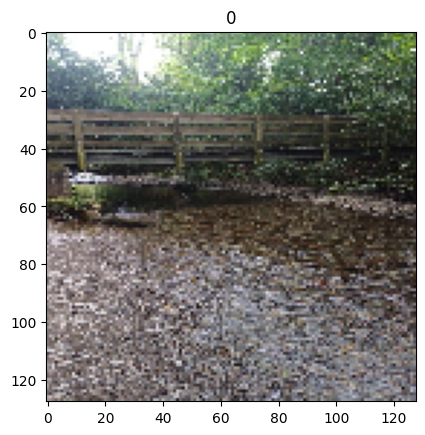

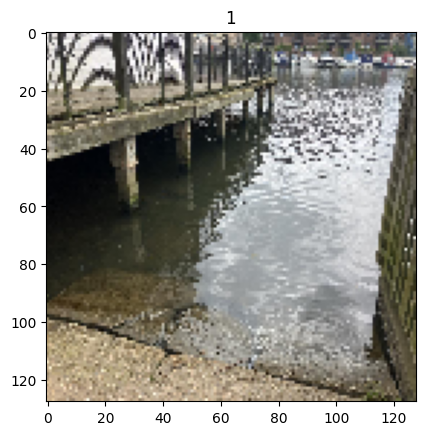

In [8]:
import matplotlib.pyplot as plt
plt.imshow(images[0])
plt.title(labels[0])
plt.show()
plt.imshow(images[120])
plt.title(labels[12])
plt.show()